# Introduction to PyTorch

Install pytorch following instruction [here](https://pytorch.org/get-started/locally/)

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder, LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim
from tqdm import tqdm
import torch.nn as nn
import pandas as pd
import numpy as np
import torch


# Fix all random seeds for full reproducibility
SEED = 17
torch.manual_seed(SEED)

# Use GPU if available, otherwise fall back to CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cpu


In [2]:
print("Loading dataset ...")
df = pd.read_csv('/Users/irene/Library/CloudStorage/OneDrive-UNIPA/UNIPA/DIDATTICA/ESAMI BD/dataset/spotify.csv')

df_labels = df['playlist_genre']

le = LabelEncoder()
labels = le.fit_transform(df_labels)

features = df[['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']]

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size=0.20,                         # Takes 20% of the data
    stratify=labels,   # Ensures 'label' proportions are kept
    random_state=SEED,                      # For reproducibility
)

# the 10% of the training set is the validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,      
    stratify=y_train,   
    random_state=SEED,                      
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on training data only
X_val_sc = scaler.transform(X_val)   # fit on training data only
X_test_sc  = scaler.transform(X_test)    # apply same transform to test

N_SAMPLES   = len(df)
N_FEATURES  = len(features.columns)
N_CLASSES   = len(df.playlist_genre.unique())

print('Dataset loaded and scaled')

Loading dataset ...
Dataset loaded and scaled


## Custom Dataset

A `Dataset` wraps raw data and exposes it through two mandatory methods:
- `__len__`  — number of samples
- `__getitem__` — returns the i-th (features, label) pair as tensors

In [ ]:
class MyDataset(Dataset):
    # Wraps a the data set in a custom PyTorch Dataset

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_set = MyDataset(X_train_sc, y_train)
val_set = MyDataset(X_val_sc, y_val)
test_set = MyDataset(X_test_sc, y_test)

print(f'Split  ->  train: {len(train_set)}  |  val: {len(val_set)}  |  test: {len(test_set)}')

# Quick sanity-check: inspect one sample
x_sample, y_sample = train_set[0]
print('Features dtype/shape:', x_sample.dtype, x_sample.shape)
print('Label dtype/value   :', y_sample.dtype, y_sample.item())

Split  ->  train: 5081  |  val: 1271  |  test: 1588
Features dtype/shape: torch.float32 torch.Size([12])
Label dtype/value   : torch.int64 0


`DataLoader` wraps a `Dataset` and handles **batching**, **shuffling**

In [ ]:
BATCH_SIZE = 16

# shuffle=True for train; no need to shuffle validation and test
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

# Verify batch shape
X_batch, y_batch = next(iter(train_loader))
print('Batch features shape:', X_batch.shape)   # (BATCH_SIZE, N_FEATURES)
print('Batch labels shape  :', y_batch.shape)   # (BATCH_SIZE,)

Batch features shape: torch.Size([16, 12])
Batch labels shape  : torch.Size([16])


## Network definition

We build a fully-connected network using `nn.Sequential` for clarity.
Key design choices:
- **ReLU** activations between linear layers
- **Dropout** after each hidden layer (structural regularization — randomly zeroes a fraction of activations during training, which prevents co-adaptation of neurons)
- **No activation on the output layer** — `nn.CrossEntropyLoss` expects raw logits and applies `log_softmax` internally
- **Custom predict function** — feedforward of the network and  applies `log_softmax` explicitely

In [5]:
DROPOUT_RATE = 0.3   # fraction of neurons to drop during each forward pass in training

class NeuralNetwork(nn.Module):
    def __init__(self, N_FEATURES, DROPOUT_RATE, N_CLASSES):
        super().__init__()

        self.net = nn.Sequential(
            # --- Input -> hidden layer 1 ---
            nn.Linear(N_FEATURES, 64),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT_RATE),

            # --- Hidden layer 2 ---
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT_RATE),

            # --- Output layer: raw logits, one per class ---
            nn.Linear(32, N_CLASSES),
        )
    
    def forward(self, x):
        logits = self.net(x) # no activation function, embedded in the loss
        return logits
    
    def predict(self, x):
        logits = self.net(x)
        pred_probab = nn.LogSoftmax(dim=1)(logits) # explicity apply activation function on evalutation
        return logits, pred_probab

In [20]:
model = NeuralNetwork(N_FEATURES, DROPOUT_RATE, N_CLASSES)

print('=== Architecture ===' )
print(model)

print('\n=== Named parameters ===')
for name, param in model.named_parameters():
    print(f'\t{name:25s}\tshape: {list(param.shape)}\trequires_grad: {param.requires_grad}')

print('\n=== Parameter count by layer ===')
for name, module in model.named_modules():
    n = sum(p.numel() for p in module.parameters(recurse=False))
    if n > 0:   # skip containers with no own parameters
        print(f'  {name or "(root)":25s}  params: {n:,}')

=== Architecture ===
NeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=6, bias=True)
  )
)

=== Named parameters ===
	net.0.weight             	shape: [64, 12]	requires_grad: True
	net.0.bias               	shape: [64]	requires_grad: True
	net.3.weight             	shape: [32, 64]	requires_grad: True
	net.3.bias               	shape: [32]	requires_grad: True
	net.6.weight             	shape: [6, 32]	requires_grad: True
	net.6.bias               	shape: [6]	requires_grad: True

=== Parameter count by layer ===
  net.0                      params: 832
  net.3                      params: 2,080
  net.6                      params: 198


## Loss function and optimizer

**L2 regularization** (weight decay) is passed directly to the optimizer.
It penalizes large weights by adding `(lambda/2) * ||w||^2` to the loss,
which discourages the model from relying too heavily on any single weight.

In [ ]:
L2_LAMBDA  = 1e-4   # weight decay coefficient (L2 regularization strength)
LR         = 1e-3   # initial learning rate

# CrossEntropyLoss = log-softmax + negative log-likelihood; expects raw logits
criterion = nn.CrossEntropyLoss()

# weight_decay adds L2 penalty to every parameter update
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=L2_LAMBDA)
# optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)

## Early stopping

Early stopping monitors the validation loss and halts training when it stops improving.
This avoids overfitting and saves the weights at the best observed checkpoint.

In [ ]:
class EarlyStopping:
    # Stops training when validation loss does not improve for `patience` consecutive epochs.
    # The best model weights are saved to disk and can be restored at the end of training.

    def __init__(self, patience = 10, min_delta = 1e-4,
                 checkpoint_path = 'best_model.pt'):
        
        # patience        -- how many epochs to wait after the last improvement
        # min_delta       -- minimum change that qualifies as an improvement
        # checkpoint_path -- file where the best state_dict is saved
        
        self.patience        = patience
        self.min_delta       = min_delta
        self.checkpoint_path = checkpoint_path

        self.best_loss   = float('inf')
        self.counter     = 0
        self.should_stop = False

    def step(self, val_loss: float, model: nn.Module):
        # Call once per epoch with the current validation loss.
        if val_loss < self.best_loss - self.min_delta:
            # Improvement found: reset counter and save checkpoint
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.checkpoint_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


early_stopping = EarlyStopping(patience=15, min_delta=1e-4, checkpoint_path='best_model.pt')
print('EarlyStopping configured with patience =', early_stopping.patience)

EarlyStopping configured with patience = 15


## Train / validation loop

Key details:
- `model.train()` enables Dropout and BatchNorm; `model.eval()` disables them.
- `torch.no_grad()` skips gradient computation during validation (saves memory and time).
- Gradients are reset with `optimizer.zero_grad()` at the start of each batch.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    # Run one full pass over the training set and return the average loss.
    model.train()   # activates Dropout layers
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        optimizer.zero_grad()                           # reset gradients from previous step
        logits = model(X_batch)                         # forward pass
        loss   = criterion(logits, y_batch)             # compute cross-entropy
        loss.backward()                                 # backpropagation
        optimizer.step()                                # update weights

        total_loss += loss.item()                       # accumulate weighted loss

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    # Evaluate the model on a DataLoader; return average loss and accuracy.
    with torch.no_grad():
        model.eval()    # deactivates Dropout layers
        total_loss, correct = 0.0, 0

        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            logits, preds = model.predict(X_batch)
            loss   = criterion(logits, y_batch)

            total_loss += loss.item()
            # Predicted class = index with the highest logit
            preds   = preds.argmax(dim=1)
            correct += (preds == y_batch).sum().item()

        avg_loss = total_loss / len(loader.dataset)
        accuracy = correct   / len(loader.dataset)
        return avg_loss, accuracy


print('Training and evaluation functions defined.')

Training and evaluation functions defined.


In [10]:
MAX_EPOCHS = 150

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in tqdm(range(1, MAX_EPOCHS + 1)):
    train_loss          = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc   = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | train loss: {train_loss:.4f} | '
              f'val loss: {val_loss:.4f} | val acc: {val_acc:.4f}')

    # Check early stopping after each epoch
    early_stopping.step(val_loss, model)
    if early_stopping.should_stop:
        print(f'\nEarly stopping triggered at epoch {epoch}. '
              f'Best val loss: {early_stopping.best_loss:.4f}')
        break

print('\nTraining complete.')

  0%|          | 0/150 [00:00<?, ?it/s]

  7%|▋         | 11/150 [00:01<00:15,  8.79it/s]

Epoch  10 | train loss: 0.0855 | val loss: 0.0803 | val acc: 0.4996


 14%|█▍        | 21/150 [00:02<00:15,  8.53it/s]

Epoch  20 | train loss: 0.0822 | val loss: 0.0786 | val acc: 0.5146


...

Epoch  50 | train loss: 0.0786 | val loss: 0.0766 | val acc: 0.5327


 41%|████      | 61/150 [00:07<00:09,  8.98it/s]

Epoch  60 | train loss: 0.0777 | val loss: 0.0764 | val acc: 0.5279


 45%|████▍     | 67/150 [00:07<00:09,  8.43it/s]


Early stopping triggered at epoch 68. Best val loss: 0.0758

Training complete.


## Training curves

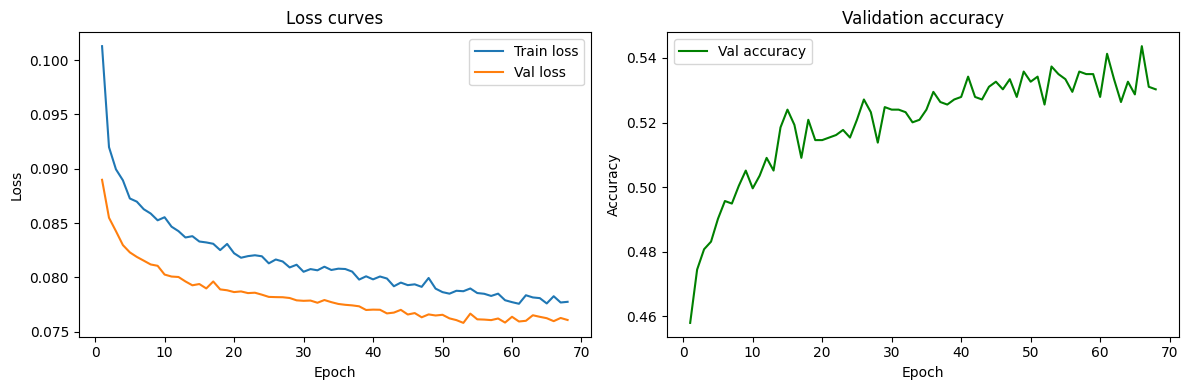

In [11]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_ran, history['train_loss'], label='Train loss')
ax1.plot(epochs_ran, history['val_loss'],   label='Val loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss curves')
ax1.legend()

ax2.plot(epochs_ran, history['val_acc'], color='green', label='Val accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

## Restoring the best checkpoint and final test evaluation

After early stopping, the model weights may reflect the last epoch rather than
the best one.  We load the checkpoint saved by `EarlyStopping`.

In [12]:
# Restore the weights that achieved the lowest validation loss during training
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f'Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}')

Test loss: 0.0787  |  Test accuracy: 0.5384


## Saving and loading the model

In [ ]:
# Save: weights only
torch.save(model.state_dict(), 'model_weights.pt')

# Save: complete checkpoint including optimizer state (useful to resume training)
torch.save({
    'epoch'               : epoch,
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_loss'            : val_loss,
}, 'full_checkpoint.pt')

print('Model saved.')

# Load weights into a new model instance
model_loaded = NeuralNetwork(N_FEATURES, DROPOUT_RATE, N_CLASSES).to(DEVICE)

model_loaded.load_state_dict(torch.load('model_weights.pt', map_location=DEVICE))
print('Weights loaded into new model instance.')

# Resume training from a full checkpoint
checkpoint  = torch.load('full_checkpoint.pt', map_location=DEVICE)
start_epoch = checkpoint['epoch'] + 1
print(f'Checkpoint from epoch {checkpoint["epoch"]} loaded. '
      f'Val loss was {checkpoint["val_loss"]:.4f}.')

Model saved.
Weights loaded into new model instance.
Checkpoint from epoch 68 loaded. Val loss was 0.0761.


## Inference

Three important rules when running the model outside a training loop:
1. Call `model.eval()` — disables Dropout so results are deterministic.
2. Wrap the forward pass in `torch.no_grad()` — suppresses gradient tracking.
3. Apply `softmax` explicitly to convert logits into interpretable probabilities.

In [ ]:
def predict(model, loader):
    # Run inference and returns predicted class indices and class probabilities and golden labels

    with torch.no_grad():
        model.eval()   
        correct = 0

        y_preds = []
        y_score = []
        y_test = []

        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            logits, preds = model.predict(X_batch)

            log_logits = nn.LogSoftmax(dim=1)(logits)

            # Predicted class = index with the highest predicted score
            preds   = preds.argmax(dim=1)
            correct += (preds == y_batch).sum().item()

            y_preds.extend(preds)
            y_score.extend(log_logits)
            y_test.extend(y_batch)

        return y_test, y_preds, torch.stack(y_score)

y_test, y_preds, y_score = predict(model_loaded, test_loader)

In [15]:
print(classification_report(y_test, y_preds, target_names=le.classes_))

              precision    recall  f1-score   support

         edm       0.69      0.64      0.66       273
       latin       0.50      0.27      0.35       232
         pop       0.40      0.37      0.38       287
         r&b       0.49      0.45      0.47       252
         rap       0.54      0.74      0.63       303
        rock       0.59      0.73      0.65       241

    accuracy                           0.54      1588
   macro avg       0.53      0.53      0.52      1588
weighted avg       0.53      0.54      0.53      1588



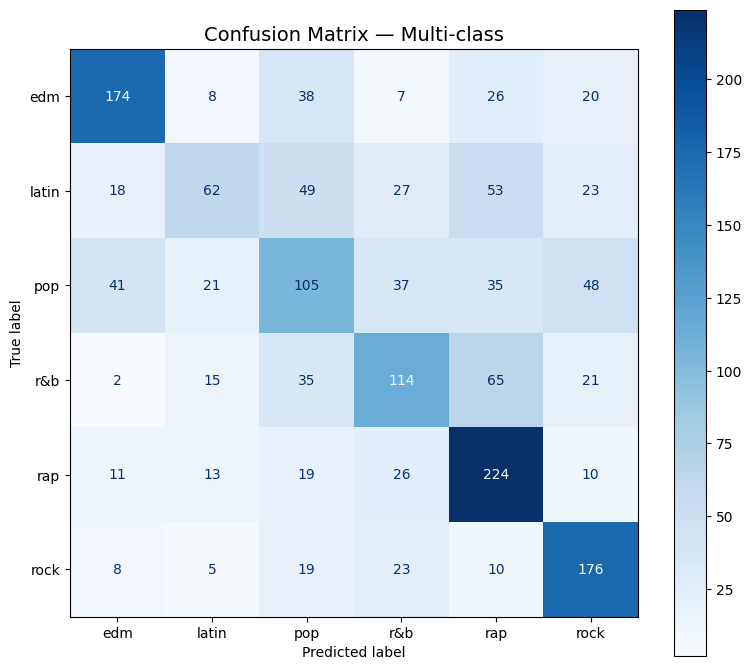

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_preds,
    display_labels=le.classes_,
    cmap='Blues',
    ax=ax
)

plt.title('Confusion Matrix — Multi-class', fontsize=14)
plt.tight_layout()
plt.show()

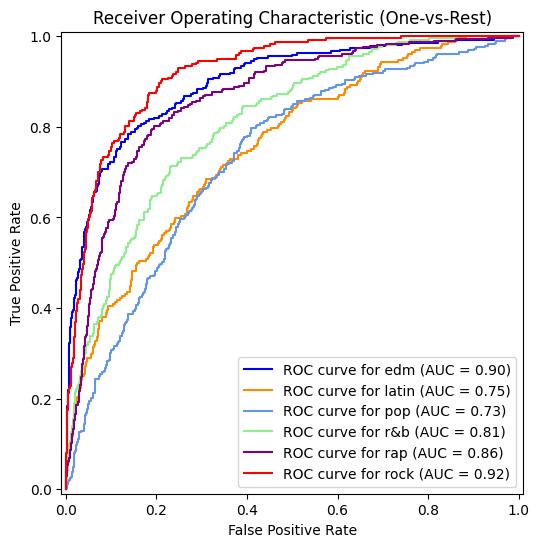

In [ ]:
label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
n_classes = len(le.classes_)

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))

colors = ['blue', 'darkorange', 'cornflowerblue', 'lightgreen', 'purple', 'red']
for class_id, color in zip(range(n_classes), colors):
    RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        y_score[:, class_id],
        name=f"ROC curve for {le.classes_[class_id]}",
        curve_kwargs=dict(color=color),
        ax=ax,
    )

ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", 
       title="Receiver Operating Characteristic (One-vs-Rest)")
plt.show()